<a href="https://colab.research.google.com/github/EhsanNikpey/machine-learning-fundamentals/blob/main/knn_on_synthetic_data_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STATISTICAL LEARNING AND NEURAL NETWORKS, A.A. 2022/2023**

**COMPUTER LAB 1** - k-NN classifier

**Duration: 6 hours**

**Exercise 1 - Synthetic dataset**

In this exercise, you will employ a synthetic dataset (file Lab1_Ex_1_Synthtetic.hdf5), containing labelled training data and test data for two classes. For each example the first two columns represent the features, while the last column represents the label.

Task: your task is to implement a k-NN classifier, which calculates the probability that a given test example belongs to each class, and outputs a class label as the class with the highest probability. You will evaluate the classifier performance computing the average classification accuracy (i.e. the fraction of test examples that have been classified correctly in respect to the full test set).

In particular, you should perform the following:

*   Train a k-NN classifier for different values of k.
*   Compare accuracy on the training set and the test set. Calculating accuracy of the training set means that you will have to classify each sample in the training set as if it were a test sample; one expects that classification of training samples will perform well, and this may also be used to validate your implementation. Accuracy is defined as the ratio between the number of test samples that are correctly classified, and the total number of test samples. Create a graph using the matplotlib library showing the evolution of the accuracy for different values of k over the test set. Create a second graph to show the evolution of the accuracy for different values of k over the train set and compare the two.

*   Identifying overfitting and underfitting in the obtained results.

Note that, for this computer lab, you do not need to employ a validation set.

**Other indications:**
*   The student is required to implement the k-NN algorithm from scratch. Only the numpy library is allowed, while other libraries such as scikit_learn are forbidden.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

#Implement a function to compute the Euclidean distance between two vectors, and one to implement the k-NN algorithm by:
#   - Taking a sample
#   - Computing all the distances between the sample element and the elements of the training set
#   - sort the the training set based on the distances to the element (the use of functions like np.argsort is allowed)
#   - select the top k elements in terms of distance
#   - evaluate to which class the majority of these k elements belongs to (e.g., it is possible to use the function np.unique with the option return_counts=True and the function np.argmax)

In [ ]:
#Change the path to match the position of your file
#The Dataset can be loaded using thhe file option in Google Colab (the directory icon on the left)
Dataset1 = h5py.File('Lab1_Ex_1_Synthtetic.hdf5')
Data = np.array(Dataset1.get('Dataset'))

Train_Set = Data[:200,:]
Test_Set = Data[200:,:]

In [ ]:
def calculate_distance(x1,x2):               #define a function to calculate the Euclidean (ایکلدین) distance
  return np.sqrt((x1[0]-x2[0])**2 + (x1[1]-x2[1])**2)

In [ ]:
def KNN (Train,Test,k):
  class1_counter=0             #here we want to define KNN by a function and the use it every time
  class2_counter=0
  distances = []
  counter = 0
  for sample in Test:        #we get the first parameter of test and calculate distance of it with all of train parameters
    for sample2 in Train:     #and then append each result to a empty list that created before
      distances.append(calculate_distance(sample,sample2))
    dis = np.argsort(distances)
    for i in dis[:k]:        #we sort the list of distances by np.argsort since it save data by its location and we can easily acsses to it
      if Test[i][2]==0:    #as the k can change, i mean we dont know how many of neighbors we want to compare our data with, so run for until K
        class1_counter+=1  #see data is from class 1 or 2 to lable it
      else:
        class2_counter+=1
    if class1_counter>class2_counter:   #if most neighbors belong to class 1 or 2 the data will lable to that exact class
      label=0
    else:
      label=1
    if label == sample[2]:   #if the guessed lable be the same as the real lable, we will ad 1 to our counter as true guess
      counter+=1
    distances = []
    class1_counter=0
    class2_counter=0
  return counter/Test.shape[0]    #finally, devide the number of true guess to all the data to see the accuracy


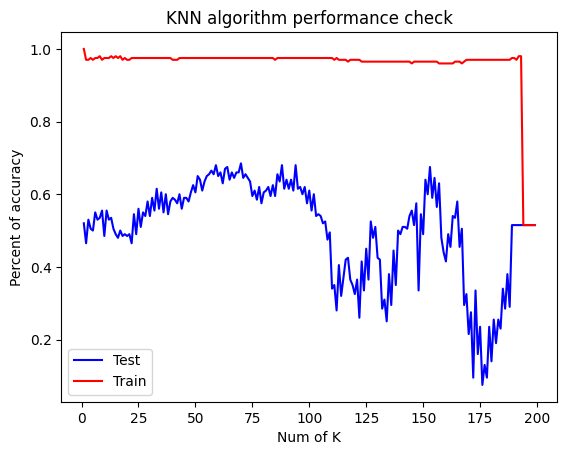

In [ ]:
train_accuracy = []
test_accuracy = []

for k in range(1, 200):
  train_accuracy.append(KNN(Train_Set,Train_Set,k))
  test_accuracy.append(KNN(Train_Set,Test_Set,k))

plt.plot(range(1, 200), test_accuracy, label="Test", color="blue")
plt.plot(range(1, 200), train_accuracy, label="Train", color="red")
plt.xlabel("Num of K")
plt.ylabel("Percent of accuracy")
plt.title("KNN algorithm performance check")
plt.legend()
plt.show()

**Accuracy Comparison and Insights**: The results reveal distinct trends in the training and testing accuracies as the value of
k increases. For smaller
k, the training accuracy is generally very high, often reaching 100%, since each training sample effectively acts as its own nearest neighbor. However, testing accuracy for small
k tends to be lower due to overfitting; the classifier relies too heavily on specific data points and fails to generalize well to unseen samples. As
k increases, the testing accuracy improves up to a certain point because the algorithm incorporates a larger number of neighbors, which stabilizes predictions and accounts for noise in the data. However, beyond a certain
k, testing accuracy starts to decline due to underfitting, where the model overly smooths its decision boundary and loses its ability to distinguish between classes effectively.

**Overfitting and Underfitting Identification**: The plots clearly depict the trade-off between overfitting and underfitting. For very small
k, overfitting occurs because the model focuses excessively on individual data points, leading to erratic decision boundaries. For very large
k, underfitting becomes evident as the model averages over an excessively broad neighborhood, causing it to miss finer class distinctions. The gap between training and testing accuracies narrows for intermediate
k, indicating a balance between these extremes and achieving the best generalization performance. Identifying the optimal
k value involves selecting the point where testing accuracy peaks while keeping training and testing performance reasonably aligned. This optimal
k ensures the model balances complexity and generalization.

**Exercise 2 - Wine dataset**

*Part 1*

In this exercise, a real problem will be examined. The dataset used in this exercise was derived from wine quality dataset from the work "*Modeling wine preferences by data mining from physicochemical properties*" by P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.

For each element of the dataset 11 features are provided, representing different wine characteristics, such as density, pH and alcholic content, and the final column consists of a quality evaluation on a scale from 1 to 10. More information can be found at https://archive.ics.uci.edu/ml/datasets/wine+quality.

A subset of the dataset containing 400 elements is provided. Create a training set and a test set of 200 samples each. The objective is to:
*   Predict the wine quality over the test set using the k-NN algorithm and evaluating the prediction accuracy for different values of k. Create a graph using the matplotlib library showing the evolution of the accuracy for different values of k over the test set.
*   Identifying overfitting and underfitting in the obtained results.

*Part 2*

The prediction of the wine quality could also be framed as a regression. Estimate the accuracy and the Mean Square Error achieved using linear resgression. For this task is possible to use the library sklearn and the function linear_model.LinearRegression()

In [ ]:
#Part 1

Dataset2 = h5py.File('Lab1_Ex_2_wine.hdf5')

Data = np.array(Dataset2.get('Dataset'))

Train_Set = Data[:200,:]
Test_Set = Data[200:,:]

In [ ]:
def k_nn_predict(train_data, test_sample, k):
  distances = []  # Initialize a list to store distances between the test sample and all training samples
  # Calculate the distance between the test sample and each training sample
  for train_sample in train_data:
    # Compute the Euclidean distance (ignoring the label, i.e., the last column)
    distance = calculate_distance(test_sample[:-1], train_sample[:-1])
    # Append the distance and the corresponding label (quality) of the training sample
    distances.append((distance, train_sample[-1]))
  # Sort the distances in ascending order (nearest neighbors first)
  distances.sort(key=lambda x: x[0])
  # Select the top-k nearest neighbors
  neighbors = distances[:k]
  # Extract the quality labels of the k-nearest neighbors
  neighbor_qualities = [neighbor[1] for neighbor in neighbors]
  # Calculate the prediction by averaging the neighbor qualities and rounding to the nearest integer
  prediction = round(np.mean(neighbor_qualities))
  return prediction  # Return the predicted wine quality


In [ ]:
def evaluate_knn(train_data, test_data, k):
  correct_predictions = 0  # Initialize a counter for correct predictions
  # Loop through each sample in the test set
  for test_sample in test_data:
    # Predict the quality of the current test sample using k-NN
    prediction = k_nn_predict(train_data, test_sample, k)
    # Check if the prediction matches the true quality (last column of the test sample)
    if prediction == test_sample[-1]:
      correct_predictions += 1  # Increment the counter if the prediction is correct
  # Calculate and return the accuracy as the fraction of correctly predicted samples
  return correct_predictions / len(test_data)

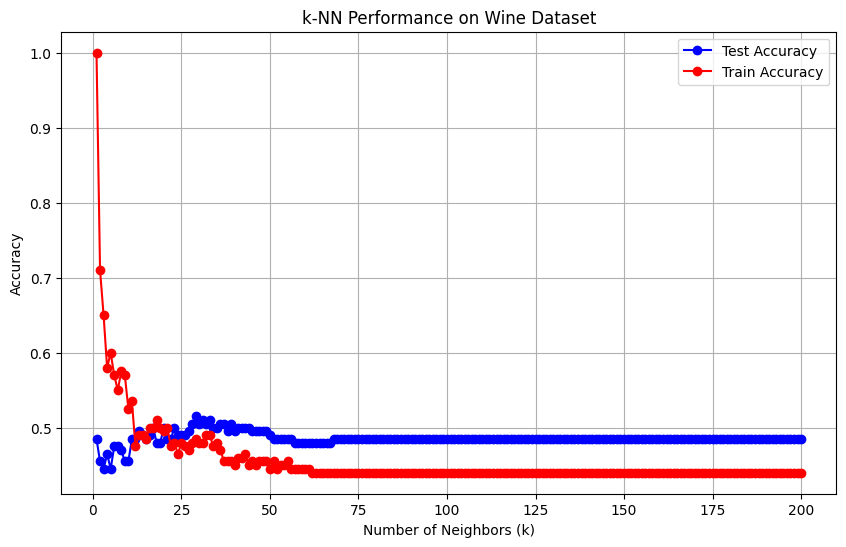

In [ ]:
test_accuracies = []  # Initialize a list to store test set accuracies for different values of k
train_accuracies = []  # Initialize a list to store training set accuracies for different values of k
k_values = range(1, 201)  # Define the range of k values to evaluate (from 1 to 200)
# Loop through each value of k to evaluate performance
for k in k_values:
  # Calculate the accuracy on the test set for the current value of k
  accuracy = evaluate_knn(Train_Set, Test_Set, k)
  test_accuracies.append(accuracy)  # Append the test accuracy to the list
  # Calculate the accuracy on the training set for the current value of k
  train_accuracy = evaluate_knn(Train_Set, Train_Set, k)
  train_accuracies.append(train_accuracy)  # Append the training accuracy to the list
# Plot the results
plt.figure(figsize=(10, 6))  # Create a new figure with a specified size
plt.plot(k_values, test_accuracies, label="Test Accuracy", marker='o', color="blue")  # Plot test accuracies
plt.plot(k_values, train_accuracies, label="Train Accuracy", marker='o', color="red")  # Plot training accuracies
plt.xlabel("Number of Neighbors (k)")  # Label the x-axis as "Number of Neighbors (k)"
plt.ylabel("Accuracy")  # Label the y-axis as "Accuracy"
plt.title("k-NN Performance on Wine Dataset")  # Add a title to the plot
plt.legend()  # Add a legend to distinguish between test and train accuracies
plt.grid()  # Add a grid for better visualization
plt.show()  # Display the plot


**Accuracy Trends for Different Values of 𝑘:**
The graph clearly shows how the accuracy on both the training and test sets evolves as
𝑘 increases. For smaller values of
𝑘 (e.g.,
𝑘=1), the training accuracy is very high because the classifier essentially memorizes the training data. However, the test accuracy is lower, indicating overfitting, as the model fails to generalize well to unseen data. As
𝑘 increases, the test accuracy improves initially, indicating that the model is generalizing better by considering more neighbors to make predictions. However, after a certain point, the test accuracy plateaus or starts to decrease slightly, suggesting underfitting, as the model becomes too generalized and loses its ability to capture subtle patterns.

**Overfitting and Underfitting Observation:**
The training accuracy decreases steadily as
𝑘 increases because the model relies on more neighbors, making it less sensitive to individual training samples. On the other hand, the test accuracy typically peaks at a moderate
𝑘 value (e.g., 10–30, depending on the dataset) before it starts to decline. This pattern is typical for k-NN, where very low values of
𝑘 lead to overfitting, while very high values lead to underfitting. Striking a balance by choosing an optimal
𝑘 is critical for achieving the best performance on the test set. The gap between the training and test accuracy further highlights the trade-off between bias and variance in the k-NN algorithm.

In [ ]:
#Part 2
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
clf = linear_model.LinearRegression()

In [ ]:
def regression(Train,Test):
  counter = 0
  x_train = Train_Set[:,:-1]
  y_train = Train_Set[:,-1]  #split the data to x_train and y_train and x_test and y_test
  y_test = Test_Set[:,-1]    #because we can use it simpler this way
  x_test = Test_Set[:,:-1]
  clf.fit(x_train,y_train) #fit our data to the regression
  prediction = clf.predict(x_test)  #predict based of train part for the test part
  mse = mean_squared_error(y_test, prediction)   #calculate the mse and r2
  r2 = r2_score(y_test, prediction)
#note that the mean_squared_error formula is (1/n) * Σ(y_pred - y_actual)^2
#and also r2 formula is 1 - ((sum(actual_value - predicted_value)**2)/sum(actual_value - mean)**2)
  print('Mean Squared Error : ', mse)
  print('R^2 Score: ',{r2})


In [ ]:
regression(Train_Set,Test_Set)

Mean Squared Error :  0.6067150439571319
R^2 Score:  {0.2054543688356053}


**Mean Squared Error (MSE):**
The Mean Squared Error (MSE) provides a measure of how well the linear regression model predicts wine quality. A lower MSE value indicates that the predicted wine quality is closer to the actual values in the test set, while a higher MSE suggests greater deviation. The MSE value obtained reflects the average squared difference between predicted and actual wine quality ratings, which allows us to assess the model's overall prediction performance.

 **𝑅
2 Score:**
The
𝑅
2
  score (coefficient of determination) measures the proportion of variance in the wine quality that the regression model can explain. An
𝑅
2
  score closer to 1 indicates that the model captures a significant portion of the variation in wine quality based on its features. Conversely, an
𝑅
2
  value closer to 0 suggests that the model fails to explain the variability in the dataset. The obtained
𝑅
2
  score provides insight into how well the linear regression approach models the relationship between the physicochemical properties and wine quality.

**Exercise 3: Phoneme Dataset**

In this exercise the Phoneme dataset is examined https://catalog.ldc.upenn.edu/LDC93s1. Each line represents 256 samples gathered at a 16 kHz of different speech signals. The objective is to classify wether the sound emitted is a "sh", "iy", "dcl", "aa", "ao" phoneme.  

Again, a subset of the dataset containing 400 elements is provided. Create a training set and a test set of 200 samples each.


*   Classify the samples which compose the test set using the k-NN algorithm and evaluate the prediction accuracy for different values of k. Create a graph using the matplotlib library showing the evolution of the accuracy for different values of k over the test set.
*   Identifying overfitting and underfitting in the obtained results.

In [ ]:
Dataset3 = h5py.File('Lab1_Ex_3.hdf5')

Data = np.array(Dataset3.get('Dataset'))

Train_Set = Data[:200,:]
Test_Set = Data[200:,:]

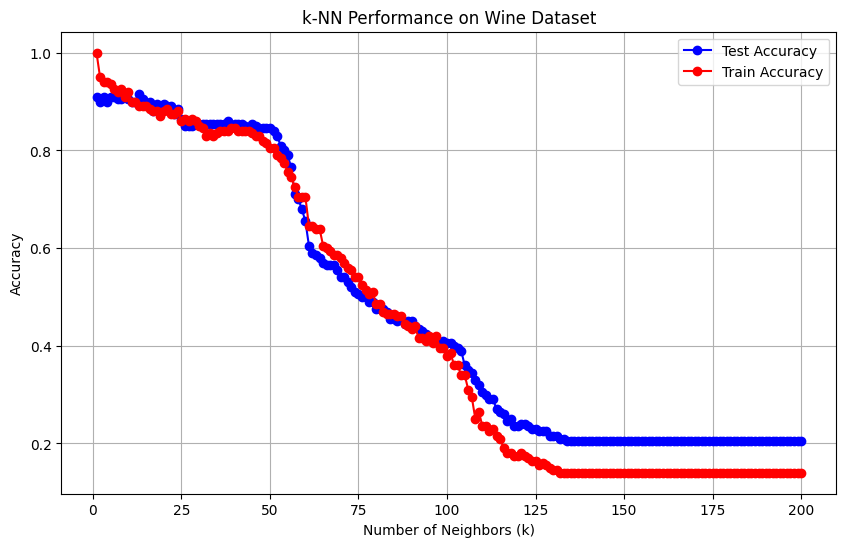

In [ ]:
test_accuracies = []  # Initialize a list to store test set accuracies for different values of k
train_accuracies = []  # Initialize a list to store training set accuracies for different values of k
k_values = range(1, 201)  # Define the range of k values to evaluate (from 1 to 200)
# Loop through each value of k to evaluate performance
for k in k_values:
  # Calculate the accuracy on the test set for the current value of k
  accuracy = evaluate_knn(Train_Set, Test_Set, k)
  test_accuracies.append(accuracy)  # Append the test accuracy to the list
  # Calculate the accuracy on the training set for the current value of k
  train_accuracy = evaluate_knn(Train_Set, Train_Set, k)
  train_accuracies.append(train_accuracy)  # Append the training accuracy to the list
# Plot the results
plt.figure(figsize=(10, 6))  # Create a new figure with a specified size
plt.plot(k_values, test_accuracies, label="Test Accuracy", marker='o', color="blue")  # Plot test accuracies
plt.plot(k_values, train_accuracies, label="Train Accuracy", marker='o', color="red")  # Plot training accuracies
plt.xlabel("Number of Neighbors (k)")  # Label the x-axis as "Number of Neighbors (k)"
plt.ylabel("Accuracy")  # Label the y-axis as "Accuracy"
plt.title("k-NN Performance on Wine Dataset")  # Add a title to the plot
plt.legend()  # Add a legend to distinguish between test and train accuracies
plt.grid()  # Add a grid for better visualization
plt.show()  # Display the plot


**Analysis of Accuracy Trends:**
The plotted results demonstrate how the accuracy on the training and test sets evolves as the number of neighbors (𝑘) increases. For smaller
𝑘 values, the k-NN classifier achieves high accuracy on the training set, indicating that it memorizes specific training samples. However, the test set accuracy may be lower for small
𝑘, as the model becomes overly sensitive to noise and variations, leading to overfitting. As
𝑘 increases, the model begins to average over more neighbors, which generally stabilizes the test set accuracy and reduces overfitting, although excessive smoothing at very high
𝑘 values can lead to underfitting.

**Overfitting and Underfitting Behavior:**
The difference between training and test accuracy highlights the presence of overfitting or underfitting. A significant gap, especially for small
𝑘, indicates overfitting, where the model performs well on training data but struggles on unseen test samples. Conversely, as
𝑘 becomes excessively large, both training and test accuracies may decline, signaling underfitting where the model fails to capture sufficient patterns from the data. An optimal value of
𝑘 balances these effects, where both accuracies reach a near-maximum and exhibit minimal discrepancy, ensuring the classifier generalizes effectively to new data.